# Vector to masks

<!-- markdownlint-disable MD033-->
<div class="page-subtitle">
Converting polygon annotations into raster labels aligned with imagery
</div>
<!-- markdownlint-enable MD033 -->

---

## 1. Motivation

{term}`Semantic segmentation` models predict a class for every pixel, which means their training labels also need to be per-pixel. A polygon file on its own does not have that structure; it needs to be converted onto the same grid as the imagery first.

---

## 2. Core idea

**Rasterization** takes vector geometries and "burns" them onto a raster grid that matches a reference image's resolution, extent, and {term}`CRS <Coordinate Reference System>`, assigning a pixel value wherever a geometry overlaps that pixel.

---

## 3. Workflow

### A. Define an output mask path

In [1]:
from pathlib import Path

import geoai

DATA_DIR = Path("data/raw")
DATA_DIR.mkdir(parents=True, exist_ok=True)

raster_url = "https://data.source.coop/giuz/sds320/L04/data/willisau_2024_swissimage_rgb_subset_05m.tif"
vector_url = "https://data.source.coop/giuz/sds320/L04/data/willisau_2024_swissbuildings3D_clip.geojson"
raster_path = geoai.download_file(
    raster_url, output_path=str(DATA_DIR / Path(raster_url).name)
)
vector_path = geoai.download_file(
    vector_url, output_path=str(DATA_DIR / Path(vector_url).name)
)

Use a clear output path so the mask is easy to find and document.

In [2]:
output_path = vector_path.replace(".geojson", ".tif")
output_path

'data/raw/willisau_2024_swissbuildings3D_clip.tif'

### B. Rasterise vector polygons

Use the source image as the reference raster. This makes the output mask match the image grid.

In [3]:
geoai.vector_to_raster(
    vector_path,
    output_path,
    reference_raster=raster_path,
)

array([[0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       ...,
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0]], shape=(1031, 2181), dtype=uint8)

assing `reference_raster=raster_path` is what makes the output mask share the exact same resolution, extent, and CRS as the source imagery. Without this, the mask and the image could end up on subtly different grids, which would misalign every pixel comparison you make later.

### C. Visualise the mask

Check the created mask before using it for chips.

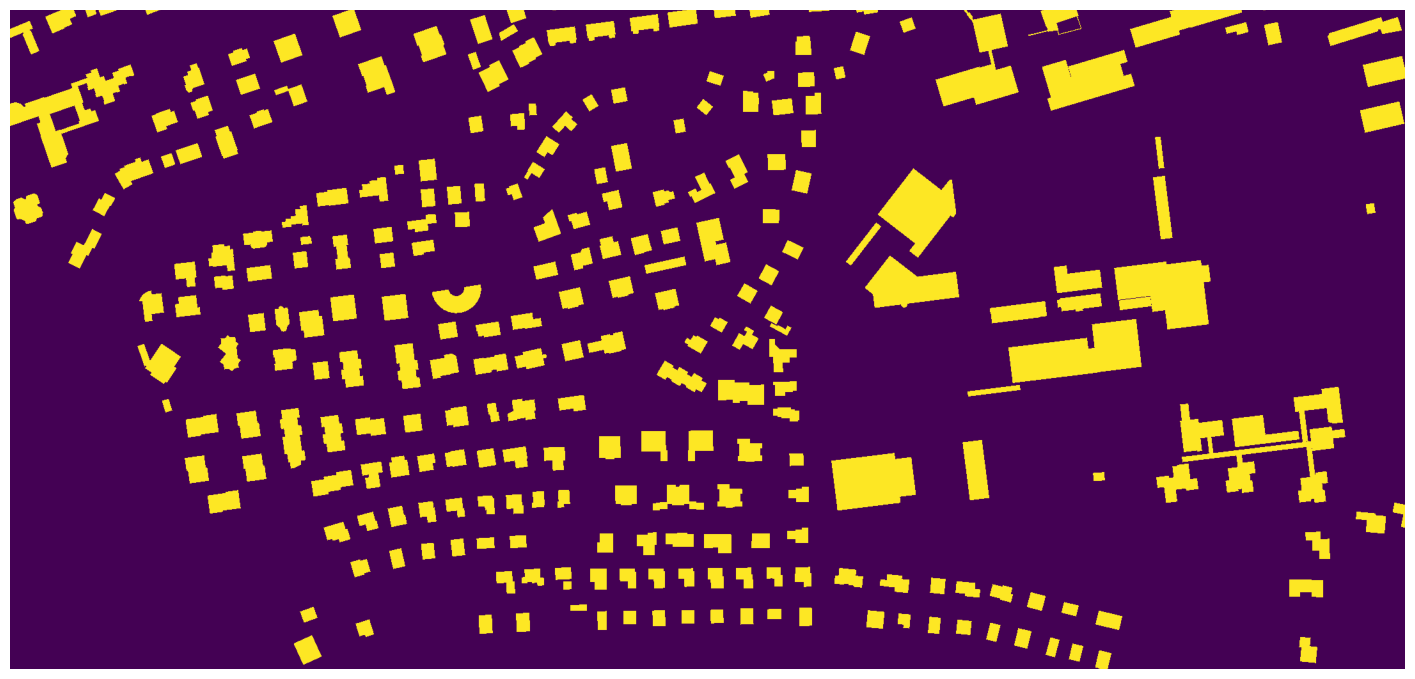

In [4]:
geoai.view_image(output_path, figsize=(18, 10))

The resulting building mask shows building pixels as a separate value from the background. This is the pixel-level label image used for segmentation-style training.

### D. Document the class values

The exact values depend on the task. A binary mask has two values. A multi-class mask may use several integer class IDs.

Example:

```text
0 = background
1 = building
2 = road
3 = vegetation
```

Document these values clearly. A mask without class-value documentation is difficult to reuse.

### E. Control edge cases

Two things matter most in practice, though you will not always need to change them: **buffering**, which expands each geometry slightly outward before rasterizing and is useful for correcting small, systematic misalignments between imagery and annotations; and an **all_touched** option, which marks a pixel as part of a feature if the geometry touches it at all, rather than only when the pixel's center falls inside the geometry. This matters most for small or thin features that might otherwise be missed entirely. Note that `vector_to_raster()` has no `buffer_radius` argument of its own — buffer the geometries yourself with GeoPandas before passing them in, as shown below.

```{admonition} One raster per class value
:class: tip
For a binary task like "building or not building," a single output value of 0 or 1 is enough. For multi-class problems (several land-cover types, for example), an `attribute_field` parameter lets `vector_to_raster()` assign a different integer to each class based on an attribute column in your vector file.
```

In [5]:
import geopandas as gpd
import rasterio

MASKS_DIR = Path("output/mask_comparison")
MASKS_DIR.mkdir(parents=True, exist_ok=True)

mask_default_path = str(MASKS_DIR / "mask_default.tif")
mask_buffered_path = str(MASKS_DIR / "mask_buffered.tif")
mask_all_touched_path = str(MASKS_DIR / "mask_all_touched.tif")

# Default: no buffer, center-of-pixel rule only
geoai.vector_to_raster(
    vector_path,
    mask_default_path,
    reference_raster=raster_path,
)

# With a buffer: expands each building outline outward before rasterizing.
# vector_to_raster() has no buffer_radius argument, so buffer the geometries
# yourself first. Buffer in the reference raster's CRS so the distance is in
# its units (meters in the Swiss LV95 grid, EPSG:2056), then pass the buffered
# GeoDataFrame directly instead of a file path.
with rasterio.open(raster_path) as src:
    raster_crs = src.crs

buildings_buffered = gpd.read_file(vector_path).to_crs(raster_crs)
buildings_buffered["geometry"] = buildings_buffered.buffer(10.0)

geoai.vector_to_raster(
    buildings_buffered,
    mask_buffered_path,
    reference_raster=raster_path,
)

# With all_touched: any pixel touched by a geometry counts,
# not only pixels whose center falls inside it
geoai.vector_to_raster(
    vector_path,
    mask_all_touched_path,
    reference_raster=raster_path,
    all_touched=True,
)

array([[0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       ...,
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0]], shape=(1031, 2181), dtype=uint8)

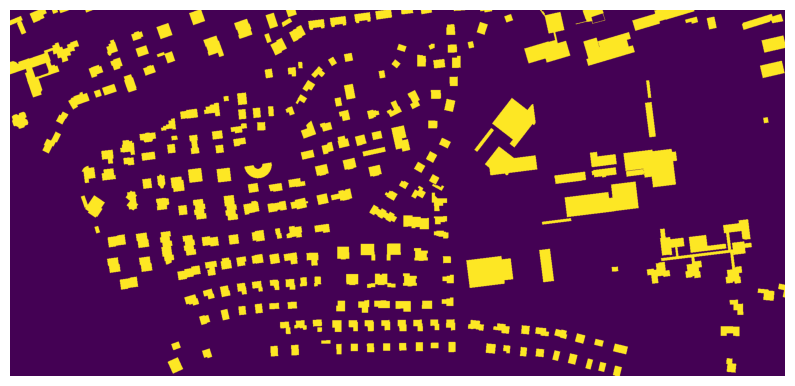

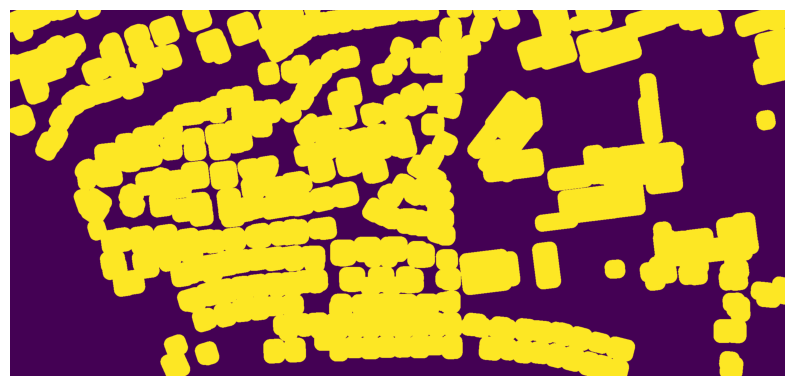

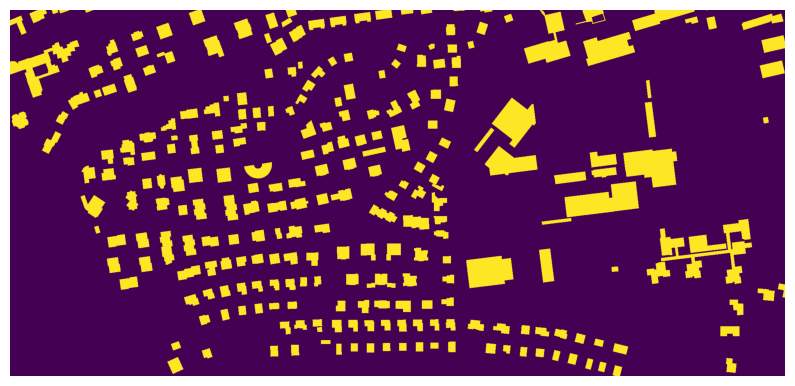

In [6]:
geoai.view_image(mask_default_path, figsize=(10, 7))
geoai.view_image(mask_buffered_path, figsize=(10, 7))
geoai.view_image(mask_all_touched_path, figsize=(10, 7))

Look closely at the same handful of small buildings across the three outputs:

- In `mask_default.tif`, very narrow structures (sheds, carports) may appear thinner than in the vector file, or vanish entirely if no pixel center falls inside them.
- In `mask_buffered.tif`, every building appears clearly larger than in the default mask, since the geometries were buffered outward by 10 m (20 pixels at the 0.5 m resolution of this image) before rasterizing. This deliberately large value makes the effect easy to see. To correct annotations that are systematically a pixel or two off from the true building edges, a buffer of about 0.5–1 m would be appropriate for this imagery.
- In `mask_all_touched.tif`, thin or small features that disappeared in the default mask should now be at least partially visible, since a geometry only needs to touch a pixel, not contain its center, to be included.

```{tip}
Buffering and all-touched solve different problems: buffering corrects *position* (labels that are shifted relative to the imagery), while all-touched corrects *omission* (small features that fall through the cracks of the default center-of-pixel rule). Try several buffer distances, like `1.0`, `3.0` and `10.0`, on your own data to see how far you can push it before buildings start visibly merging into their neighbors.
```

---

## 4. Python reactivation

`vector_path.replace(".geojson", ".tif")` is ordinary Python string manipulation, the same pattern you used constantly in SDS210 to derive one file path from another. It is a small habit worth keeping: deriving output paths from input paths, rather than typing them separately, reduces the chance of accidentally pointing two variables at mismatched files.

---

## 5. Common pitfalls

- **Forgetting `reference_raster`.** Without it, the output mask may not share the same grid as your imagery, which breaks the pixel-for-pixel correspondence segmentation training depends on.
- **Assuming rasterization is lossless.** Very small or thin features (narrow roads, small outbuildings) can disappear entirely at coarse resolutions unless you use the all-touched option.
- **Not checking class value assignment for multi-class masks.** If your vector file's class attribute is inconsistent (mixed types, missing values), the resulting mask can silently assign the wrong class to some features.

---

## 6. Mini task

Using your own project's checked image/annotation pair from the previous page (or the sample data here), rasterize the annotation and visually compare the output mask against the original vector overlay.

:::{note} Sample solution
:class: dropdown

```python
output_path = vector_path.replace(".geojson", ".tif")
geoai.vector_to_raster(vector_path, output_path, reference_raster=raster_path)
geoai.view_image(output_path, figsize=(12, 8))
```

The rasterized mask reproduces the building footprints as filled pixel blocks in the same locations as the original polygons. A few very narrow structures (likely carports or sheds) appear thinner or slightly broken up in the raster version compared to the vector outline, which is a sign that the all-touched option might be worth enabling for this particular dataset.
:::

---

## 7. Key takeaways

- Rasterization converts vector annotations into the pixel-level masks that segmentation models require.
- `vector_to_raster()` needs a `reference_raster` to guarantee the output mask shares the source imagery's resolution, extent, and CRS.
- Buffering the vector geometries yourself (there is no built-in `buffer_radius` argument) and the `all_touched` option help correct small misalignments and preserve small or thin features.
- An `attribute_field` extends the same process to multi-class masks.

### Useful links

- [GeoAI Video Tutorial](https://youtu.be/B9FymJwJr0g?si=do8TzwGR4xFnW2Wn) - edit existing labeled dataset for deep learning